**BOSTON BLUEBIKES: ANALYZING BIKE-SHARING DEMAND THROUGH TIME, RIDER BEHAVIOR & WEATHER**

Introduction:

Bluebikes is a public bicycle-sharing system in the Boston, Massachusetts area, where people can rent bicycles from one station and return them at another station. The service is used by both member and casual riders for everyday travel, commuting, and other short trips.

This project analyzes historical Bluebikes data to understand when and how people use shared bicycles. It focuses on bike demand, rider behavior, time patterns, and weather conditions such as temperature, humidity, and wind speed.

The analysis uses Exploratory Data Analysis (EDA) techniques, including data cleaning, statistical analysis, and visualizations, to identify important patterns and relationships. The findings can help understand peak demand periods, rider usage patterns, and the effect of weather on bike usage, providing useful insights for better bike availability and operational planning.

Problem Statement:

Bike-sharing demand is not the same at all times. It can change depending on the time of day, day of the week, rider type, and weather conditions. This makes it difficult for bike-sharing operators to know when demand will be high or low and plan bike availability accordingly.

This project focuses on analyzing Boston Bluebikes data to understand these demand patterns, compare member and casual rider behavior, and examine how weather conditions are associated with bike usage. The goal is to identify useful patterns and insights that can support better demand planning, bike availability, and operational decisions.

Objective Of The Project:

The main objective of this project is to analyze Boston Bluebikes usage and understand the factors that influence bike-sharing demand. The project focuses on studying how bike demand changes across different hours, days, months, weekdays, weekends, and holidays. It also aims to compare the usage patterns of member and casual riders and examine how weather conditions such as temperature, humidity, and wind speed are associated with bike usage. Through Exploratory Data Analysis (EDA), the project aims to identify important patterns, relationships, peak-demand periods, and low-demand periods, and convert these findings into useful business insights and recommendations for better bike availability, demand planning, and operational efficiency.

Business Quetions

1.How does bike-sharing demand vary across different hours of the day?

2.Which days and time periods have the highest and lowest bike-sharing demand?

3.How does bike usage differ between member and casual riders?

4.How does bike-sharing demand differ between weekdays and weekends?

5.Does holiday status have an impact on bike-sharing demand?

6.How are temperature, humidity, and wind speed associated with bike-sharing demand?

7.Which weather conditions are associated with higher or lower bike-sharing demand?

8.What patterns in time, rider behavior, and weather can help improve bike availability and demand planning?

DATA UNDERSTANDING:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("/content/bluebike_data (1).csv")


In [ ]:
df.head()

,Unnamed: 0,casual_riders_count,member_riders_count,casual_rider_duration,member_rider_duration,count,travel_time,day_of_week,IsWeekend,IsHoliday,Temp(c),rel_humidity,wspd,pres,weather_condition
0,2022-01-01 00:00:00,28.0,97.0,554672.0,96509.0,125.0,651181.0,SATURDAY,1,1,6.7,89.0,7.6,1014.9,Cloudy
1,2022-01-01 01:00:00,31.0,61.0,46276.0,58472.0,92.0,104748.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
2,2022-01-01 02:00:00,32.0,41.0,377839.0,45191.0,73.0,423030.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
3,2022-01-01 03:00:00,54.0,41.0,2537734.0,37167.0,95.0,2574901.0,SATURDAY,1,1,6.7,96.0,5.4,1014.2,Cloudy
4,2022-01-01 04:00:00,49.0,42.0,911448.0,43178.0,91.0,954626.0,SATURDAY,1,1,7.2,93.0,5.4,1014.4,Cloudy


Observations:

1.The dataset contains hourly Boston Bluebikes data with rider activity, travel time, time-related information, and weather conditions.

2.It includes casual and member rider counts, total bike usage, and rider duration, which help analyze rider behavior and demand.

3.Categorical Data: day_of_week, weather_condition.

3.Binary Data: IsWeekend, IsHoliday.

4.Numerical Data: casual_riders_count, member_riders_count, casual_rider_duration, member_rider_duration, count, travel_time, Temp(c), rel_humidity, wspd, and pres.

5.Date/Time Data: timestamp, which can be used to analyze demand by hour, day, month, and other time periods.

6.The dataset can be used to identify bike-sharing demand patterns and the influence of rider behavior, time, and weather conditions.

In [ ]:
df.shape

(21079, 15)

In [ ]:
df.columns

Index(['Unnamed: 0', 'casual_riders_count', 'member_riders_count',
       'casual_rider_duration', 'member_rider_duration', 'count',
       'travel_time', 'day_of_week', 'IsWeekend', 'IsHoliday', 'Temp(c)',
       'rel_humidity', 'wspd', 'pres', 'weather_condition'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21079 entries, 0 to 21078
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             21079 non-null  object 
 1   casual_riders_count    21079 non-null  float64
 2   member_riders_count    21079 non-null  float64
 3   casual_rider_duration  21079 non-null  float64
 4   member_rider_duration  21079 non-null  float64
 5   count                  21079 non-null  float64
 6   travel_time            21079 non-null  float64
 7   day_of_week            21079 non-null  object 
 8   IsWeekend              21079 non-null  int64  
 9   IsHoliday              21079 non-null  int64  
 10  Temp(c)                21079 non-null  float64
 11  rel_humidity           21079 non-null  float64
 12  wspd                   21079 non-null  float64
 13  pres                   21079 non-null  float64
 14  weather_condition      21079 non-null  object 
dtypes:

In [ ]:
df.dtypes

,0
Unnamed: 0,object
casual_riders_count,float64
member_riders_count,float64
casual_rider_duration,float64
member_rider_duration,float64
count,float64
travel_time,float64
day_of_week,object
IsWeekend,int64
IsHoliday,int64


In [ ]:
df.describe()

,casual_riders_count,member_riders_count,casual_rider_duration,member_rider_duration,count,travel_time,IsWeekend,IsHoliday,Temp(c),rel_humidity,wspd,pres
count,21079.000000,21079.000000,2.107900e+04,2.107900e+04,21079.000000,2.107900e+04,21079.000000,21079.000000,21079.000000,21079.000000,21079.000000,21079.000000
mean,106.744106,315.014137,4.110391e+05,3.111644e+05,421.758243,7.222035e+05,0.284786,0.042127,11.148484,67.295507,17.260420,1015.749462
std,127.927135,311.070313,8.341194e+05,4.320148e+05,410.429980,1.062146e+06,0.451323,0.200884,9.202060,20.171645,8.317435,8.559111
min,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.560000e+02,0.000000,0.000000,-22.800000,13.000000,0.000000,980.200000
25%,15.000000,61.000000,2.064600e+04,4.784950e+04,83.000000,8.699350e+04,0.000000,0.000000,4.400000,52.000000,11.200000,1010.500000
50%,57.000000,239.000000,1.024180e+05,1.888580e+05,307.000000,3.398950e+05,0.000000,0.000000,10.600000,68.000000,16.600000,1015.800000
75%,151.000000,464.000000,3.930615e+05,4.040475e+05,633.000000,8.864505e+05,1.000000,0.000000,18.300000,84.000000,22.300000,1021.400000
max,914.000000,2434.000000,1.852849e+07,6.981540e+06,2744.000000,1.933045e+07,1.000000,1.000000,37.200000,100.000000,79.600000,1042.300000


Observations:

1.The dataset contains 21,079 hourly observations with complete numerical values for the analyzed variables.

2.Member riders (mean: 315) are higher on average than casual riders (mean: 107), indicating greater usage by members.


3.The average total bike demand is approximately 422 rides per hour, with demand ranging from 1 to 2,434 rides.

4.Temperature ranges from -22.8°C to 31.7°C, while relative humidity ranges from 13% to 100%.

5.Wind speed ranges from 0 to 49.9, and atmospheric pressure ranges from 980.2 to 1042.2.

6.The large difference between the mean and maximum values of rider counts and duration variables suggests the presence of high-demand periods and potential outliers, which will be investigated further during EDA.

7.IsWeekend and IsHoliday are binary variables, where 0 represents No and 1 represents Yes.

DATA CLEANING

In [ ]:
#verifying duplicate values
df.duplicated().sum()

np.int64(0)

Observations:

There are no duplicate records in the dataset, indicating that each row represents a unique observation.

In [ ]:
#Dropping Duplicate values
df=df.drop_duplicates()
df


,Unnamed: 0,casual_riders_count,member_riders_count,casual_rider_duration,member_rider_duration,count,travel_time,day_of_week,IsWeekend,IsHoliday,Temp(c),rel_humidity,wspd,pres,weather_condition
0,2022-01-01 00:00:00,28.0,97.0,554672.0,96509.0,125.0,651181.0,SATURDAY,1,1,6.7,89.0,7.6,1014.9,Cloudy
1,2022-01-01 01:00:00,31.0,61.0,46276.0,58472.0,92.0,104748.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
2,2022-01-01 02:00:00,32.0,41.0,377839.0,45191.0,73.0,423030.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
3,2022-01-01 03:00:00,54.0,41.0,2537734.0,37167.0,95.0,2574901.0,SATURDAY,1,1,6.7,96.0,5.4,1014.2,Cloudy
4,2022-01-01 04:00:00,49.0,42.0,911448.0,43178.0,91.0,954626.0,SATURDAY,1,1,7.2,93.0,5.4,1014.4,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21074,2024-05-30 20:00:00,259.0,481.0,391657.0,407250.0,740.0,798907.0,THURSDAY,0,0,15.6,75.0,18.4,1014.0,Cloudy
21075,2024-05-30 21:00:00,178.0,403.0,339400.0,473918.0,581.0,813318.0,THURSDAY,0,0,15.0,67.0,14.8,1014.4,Cloudy
21076,2024-05-30 22:00:00,159.0,283.0,262118.0,230148.0,442.0,492266.0,THURSDAY,0,0,14.4,72.0,9.4,1014.6,Cloudy
21077,2024-05-30 23:00:00,91.0,161.0,166692.0,116522.0,252.0,283214.0,THURSDAY,0,0,13.9,74.0,9.4,1015.0,Cloudy


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0


#Observations:
The dataset contains no missing values in any of the columns.

Therefore, no missing-value treatment or imputation is required.

The dataset is ready for further data cleaning and EDA.

In [ ]:
##Missing values for percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0


Observations:

The dataset has 0% missing values across all columns.

No columns require missing-value treatment or imputation.

The dataset has complete data for the available variables and is suitable for further analysis.

In [ ]:
df.columns.tolist()

['Unnamed: 0',
 'casual_riders_count',
 'member_riders_count',
 'casual_rider_duration',
 'member_rider_duration',
 'count',
 'travel_time',
 'day_of_week',
 'IsWeekend',
 'IsHoliday',
 'Temp(c)',
 'rel_humidity',
 'wspd',
 'pres',
 'weather_condition']

In [ ]:
df['Unnamed: 0'].head()

,Unnamed: 0
0,2022-01-01 00:00:00
1,2022-01-01 01:00:00
2,2022-01-01 02:00:00
3,2022-01-01 03:00:00
4,2022-01-01 04:00:00


In [ ]:
df = df.rename(columns={'Unnamed: 0': 'timestamp'})

In [ ]:
df

,timestamp,casual_riders_count,member_riders_count,casual_rider_duration,member_rider_duration,count,travel_time,day_of_week,IsWeekend,IsHoliday,Temp(c),rel_humidity,wspd,pres,weather_condition
0,2022-01-01 00:00:00,28.0,97.0,554672.0,96509.0,125.0,651181.0,SATURDAY,1,1,6.7,89.0,7.6,1014.9,Cloudy
1,2022-01-01 01:00:00,31.0,61.0,46276.0,58472.0,92.0,104748.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
2,2022-01-01 02:00:00,32.0,41.0,377839.0,45191.0,73.0,423030.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy
3,2022-01-01 03:00:00,54.0,41.0,2537734.0,37167.0,95.0,2574901.0,SATURDAY,1,1,6.7,96.0,5.4,1014.2,Cloudy
4,2022-01-01 04:00:00,49.0,42.0,911448.0,43178.0,91.0,954626.0,SATURDAY,1,1,7.2,93.0,5.4,1014.4,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21074,2024-05-30 20:00:00,259.0,481.0,391657.0,407250.0,740.0,798907.0,THURSDAY,0,0,15.6,75.0,18.4,1014.0,Cloudy
21075,2024-05-30 21:00:00,178.0,403.0,339400.0,473918.0,581.0,813318.0,THURSDAY,0,0,15.0,67.0,14.8,1014.4,Cloudy
21076,2024-05-30 22:00:00,159.0,283.0,262118.0,230148.0,442.0,492266.0,THURSDAY,0,0,14.4,72.0,9.4,1014.6,Cloudy
21077,2024-05-30 23:00:00,91.0,161.0,166692.0,116522.0,252.0,283214.0,THURSDAY,0,0,13.9,74.0,9.4,1015.0,Cloudy


In [ ]:
df.columns


Index(['timestamp', 'casual_riders_count', 'member_riders_count',
       'casual_rider_duration', 'member_rider_duration', 'count',
       'travel_time', 'day_of_week', 'IsWeekend', 'IsHoliday', 'Temp(c)',
       'rel_humidity', 'wspd', 'pres', 'weather_condition'],
      dtype='object')

FEATURE ENGINEERING – CREATING NEW COLUMNS

In [ ]:
df['timestamp'].dtype

dtype('O')

In [ ]:
# Converting timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df['timestamp'].dtype

dtype('<M8[ns]')

In [ ]:
# Creating Date column
df['DATE'] = df['timestamp'].dt.date
df['DATE'].head()

,DATE
0,2022-01-01
1,2022-01-01
2,2022-01-01
3,2022-01-01
4,2022-01-01


Observation:

The DATE column was created from the timestamp to support daily bike-sharing demand analysis.

In [ ]:
# Creating Year column
df['YEAR'] = df['timestamp'].dt.year
df['YEAR'].head()

,YEAR
0,2022
1,2022
2,2022
3,2022
4,2022


Observation:

The YEAR column was created to analyze changes in bike-sharing demand across different years.

In [ ]:
# Creating Month column
df['MONTH'] = df['timestamp'].dt.month
df['MONTH'].head()

,MONTH
0,1
1,1
2,1
3,1
4,1


In [ ]:
# Creating Month Name column
df['MONTH_NAME'] = df['timestamp'].dt.month_name()
df['MONTH_NAME'].head()

,MONTH_NAME
0,January
1,January
2,January
3,January
4,January


Observation:

The MONTH_NAME column provides readable month names, making monthly analysis and visualization easier.

In [ ]:
# Creating Day column
df['DAY'] = df['timestamp'].dt.day
df['DAY'].head()

,DAY
0,1
1,1
2,1
3,1
4,1


Observation:

The DAY_NAME column was created to compare bike-sharing demand across different days of the week.

In [ ]:
# Creating Hour column
df['HOUR'] = df['timestamp'].dt.hour
df['HOUR'].head()

,HOUR
0,0
1,1
2,2
3,3
4,4


Observation:

The HOUR column was created to analyze hourly bike-sharing demand and identify peak and low-demand periods.

In [ ]:
df.columns.tolist()

['timestamp',
 'casual_riders_count',
 'member_riders_count',
 'casual_rider_duration',
 'member_rider_duration',
 'count',
 'travel_time',
 'day_of_week',
 'IsWeekend',
 'IsHoliday',
 'Temp(c)',
 'rel_humidity',
 'wspd',
 'pres',
 'weather_condition',
 'DATE',
 'YEAR',
 'MONTH',
 'MONTH_NAME',
 'DAY',
 'HOUR']

In [ ]:
df.head()

,timestamp,casual_riders_count,member_riders_count,casual_rider_duration,member_rider_duration,count,travel_time,day_of_week,IsWeekend,IsHoliday,Temp(c),rel_humidity,wspd,pres,weather_condition,DATE,YEAR,MONTH,MONTH_NAME,DAY,HOUR
0,2022-01-01 00:00:00,28.0,97.0,554672.0,96509.0,125.0,651181.0,SATURDAY,1,1,6.7,89.0,7.6,1014.9,Cloudy,2022-01-01,2022,1,January,1,0
1,2022-01-01 01:00:00,31.0,61.0,46276.0,58472.0,92.0,104748.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy,2022-01-01,2022,1,January,1,1
2,2022-01-01 02:00:00,32.0,41.0,377839.0,45191.0,73.0,423030.0,SATURDAY,1,1,6.7,89.0,7.6,1014.7,Cloudy,2022-01-01,2022,1,January,1,2
3,2022-01-01 03:00:00,54.0,41.0,2537734.0,37167.0,95.0,2574901.0,SATURDAY,1,1,6.7,96.0,5.4,1014.2,Cloudy,2022-01-01,2022,1,January,1,3
4,2022-01-01 04:00:00,49.0,42.0,911448.0,43178.0,91.0,954626.0,SATURDAY,1,1,7.2,93.0,5.4,1014.4,Cloudy,2022-01-01,2022,1,January,1,4


Final Observation for Feature Engineering:

The timestamp was converted into datetime format, and new time-based features such as DATE, YEAR, MONTH, MONTH_NAME, DAY, DAY_NAME, and HOUR were created. These features will help analyze bike-sharing demand across different time periods and identify meaningful usage patterns.

DATA VISUALIZATION

Univariate analysis

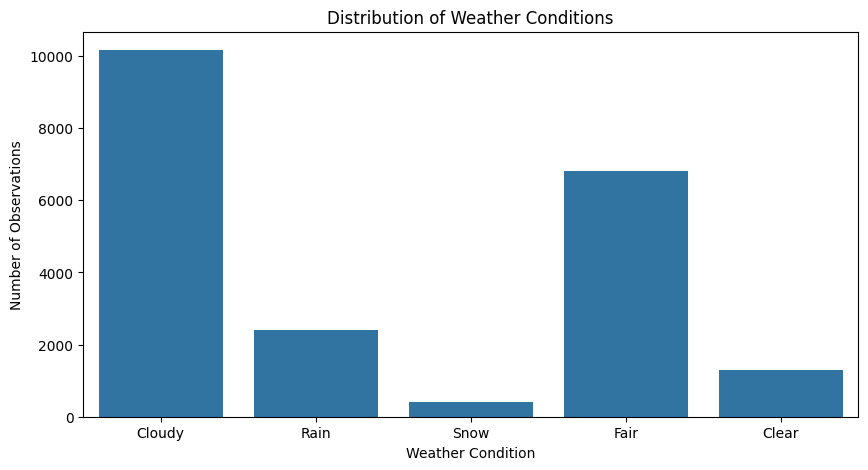

In [ ]:
#Categorical
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='weather_condition'
)

plt.title('Distribution of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Observations')
plt.show()

In [ ]:
#Which weather condition occurs most frequently in the dataset?
df['weather_condition'].value_counts().idxmax()

'Cloudy'

In [ ]:
#Which weather condition occurs least frequently in the dataset?
df['weather_condition'].value_counts().idxmin()

'Snow'

In [ ]:
#How many observations are recorded for each weather condition?
df['weather_condition'].value_counts()

,count
weather_condition,
Cloudy,10164
Fair,6800
Rain,2414
Clear,1282
Snow,419


Observations:

1.Cloudy weather condition has the highest number of observations, with 4,647 records, making it the most frequently occurring condition in the dataset.

2.Fair weather is the second most frequently observed condition, with 3,560 records.

3.Rain is observed in 1,083 records, while Clear weather is recorded in 715 observations.

4.Snow is the least frequently observed weather condition, with only 298 records.

5.The graph shows a clear difference in the frequency of weather conditions, with Cloudy and Fair conditions occurring much more frequently than Rain, Clear, and Snow.

6.Overall, the weather-condition distribution is uneven, with Cloudy conditions occurring substantially more often than the other weather categories.

Business Insight

The dataset is dominated by Cloudy and Fair weather conditions, while Snow occurs relatively rarely. Therefore, bike-sharing planning and demand analysis should primarily consider the commonly occurring weather conditions, while Snow-related demand patterns should be interpreted with caution because of the smaller number of observations.

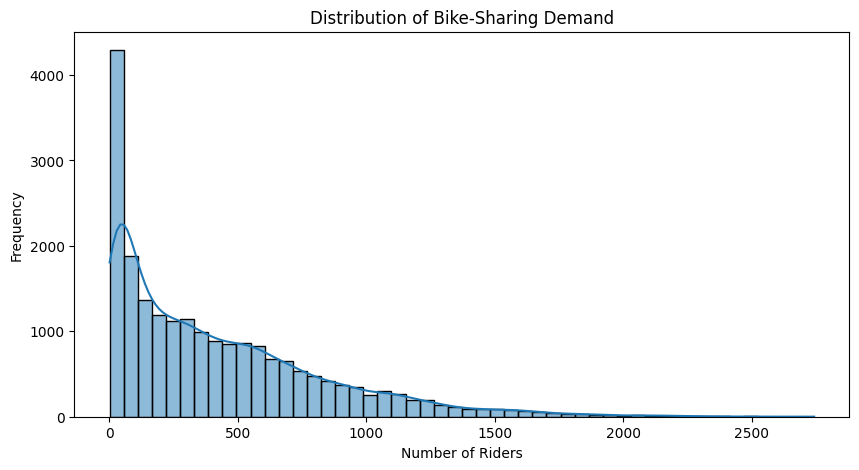

In [ ]:
#Numerical
# Distribution of Total Bike-Sharing Demand
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='count',bins=50,kde=True)
plt.title('Distribution of Bike-Sharing Demand')
plt.xlabel('Number of Riders')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# What is the average bike-sharing demand?
df['count'].mean()

np.float64(421.7582428008919)

In [ ]:
# What is the median bike-sharing demand?
df['count'].median()

307.0

In [ ]:
# What is the maximum bike-sharing demand?
df['count'].max()

2744.0

In [ ]:
# What is the minimum bike-sharing demand?
df['count'].min()

1.0

Observations

1.The distribution of bike-sharing demand is right-skewed, with most observations concentrated at lower demand levels.

2.The average bike-sharing demand is approximately 398 riders, while the median demand is 269.5 riders. The higher mean compared with the median supports the right-skewed distribution.

3.A large number of observations have relatively low bike-sharing demand, as shown by the high frequency of lower rider counts in the histogram.

4.The frequency of observations gradually decreases as the number of riders increases, indicating that very high demand occurs less frequently.

5.The bike-sharing demand ranges from a minimum of 1 rider to a maximum of 2,744 riders, showing considerable variation in demand levels.

6.Only a relatively small number of observations have very high demand, extending to more than 2,000 riders.

Business Insight:

The demand distribution indicates that typical bike-sharing demand is relatively moderate, but occasional periods experience very high demand. Therefore, the business should maintain sufficient bike availability to handle these peak-demand situations while avoiding excessive allocation during periods of lower demand.

Bivariate Analysis


In [ ]:
#Categorical vs Numerical
#2.Which days and time periods have the highest and lowest bike-sharing demand?

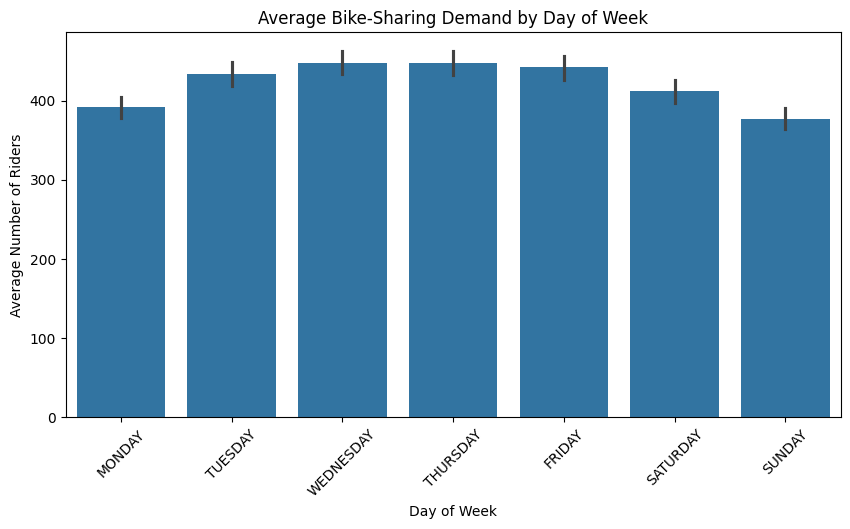

In [ ]:
# Bike-Sharing Demand by Day of Week
day_order = ['MONDAY','TUESDAY','WEDNESDAY','THURSDAY','FRIDAY','SATURDAY','SUNDAY']
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='day_of_week',y='count',order=day_order,estimator='mean')
plt.title('Average Bike-Sharing Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Number of Riders')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Which day has the highest average bike-sharing demand?
df.groupby('day_of_week')['count'].mean().idxmax()

'WEDNESDAY'

In [ ]:
# Which day has the lowest average bike-sharing demand?
df.groupby('day_of_week')['count'].mean().idxmin()

'SUNDAY'

Observations:

1.Wednesday has the highest average bike-sharing demand, followed closely by Thursday.

2.Sunday has the lowest average bike-sharing demand.

3.Tuesday, Wednesday, Thursday, and Friday show relatively higher average demand compared with Monday, Saturday, and Sunday.

4.Monday has moderate demand, while Saturday and Sunday show comparatively lower demand.

5.This indicates that bike-sharing demand varies across different days of the week.

Business Insight

Bike-sharing demand is generally higher during weekdays, with Wednesday showing the highest average demand, while demand is lowest on Sunday. This suggests that the business should ensure greater bike availability during high-demand weekdays and adjust bike allocation according to lower weekend demand.

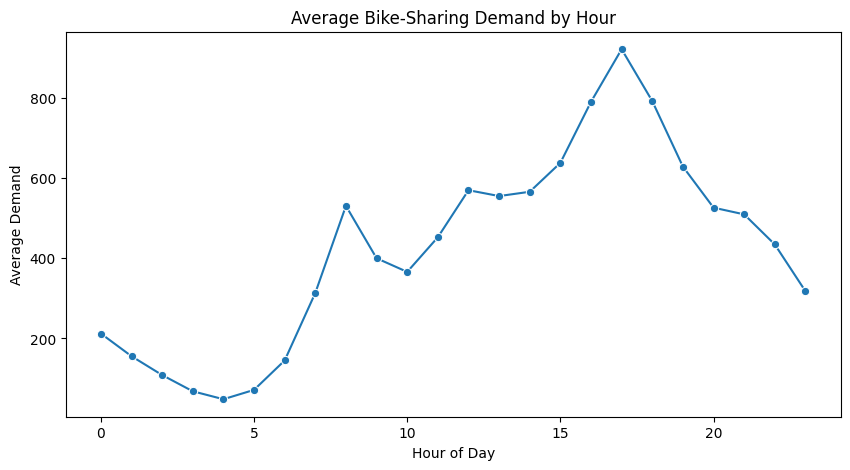

In [ ]:
#1.How does bike-sharing demand vary across different hours of the day?
# Bike-Sharing Demand by Hour
hourly_demand = df.groupby('HOUR')['count'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_demand.index,
    y=hourly_demand.values,
    marker='o'
)

plt.title('Average Bike-Sharing Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.show()

In [ ]:
# Which hour has the highest average bike-sharing demand?
df.groupby('HOUR')['count'].mean().idxmax()

np.int32(17)

In [ ]:
# Which hour has the lowest average bike-sharing demand?
df.groupby('HOUR')['count'].mean().idxmin()

np.int32(4)

In [ ]:
# How does average bike-sharing demand vary across different hours?
df.groupby('HOUR')['count'].mean()

,count
HOUR,
0,212.142045
1,155.609784
2,108.609339
3,68.157534
4,48.336758
5,71.631399
6,144.993166
7,313.428082
8,530.541810


Observation:

1.Bike-sharing demand varies significantly across different hours of the day.

2.The highest average demand occurs at 17:00 (5 PM), at approximately 921 riders.

3.The lowest average demand occurs at 04:00 (4 AM), at approximately 48 riders.

4.Demand remains low during the early morning, particularly between 2 AM and 5 AM, and starts increasing from around 6 AM.

5.Demand remains relatively high during the afternoon, particularly between 12 PM and 3 PM.

6.A sharp increase in demand occurs during the late afternoon, reaching its peak at 5 PM.

7.After the 5 PM peak, demand gradually declines through the evening and late-night hours.

8.Overall, the hourly pattern reveals distinct low-demand, growth, peak-demand, and declining-demand periods.

Business Insight:

Bike-sharing demand is strongly influenced by the time of day, with the highest demand occurring around 5 PM. Operators can use these hourly demand patterns to proactively position and rebalance bikes before peak periods and optimize operational resources during low-demand hours.

In [ ]:
#Categorical vs Numerical
#3.How does bike usage differ between member and casual riders?

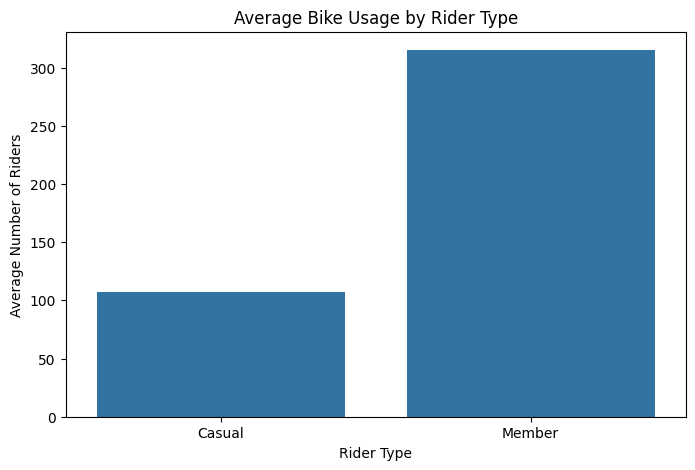

In [ ]:
rider_demand = pd.DataFrame({
    'rider_type': ['Casual', 'Member'],
    'average_count': [
        df['casual_riders_count'].mean(),
        df['member_riders_count'].mean()
    ]
})
plt.figure(figsize=(8,5))
sns.barplot(data=rider_demand,x='rider_type',y='average_count')
plt.title('Average Bike Usage by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Average Number of Riders')
plt.show()


In [ ]:
#What is the average bike usage of casual riders?
df['casual_riders_count'].mean()

np.float64(106.74410550785142)

In [ ]:
#What is the average bike usage of member riders?
df['member_riders_count'].mean()

np.float64(315.01413729304045)

In [ ]:
#Which rider type has higher average bike usage?
df[['casual_riders_count', 'member_riders_count']].mean().idxmax()

'member_riders_count'

In [ ]:
#Which rider type has lower average bike usage?
df[['casual_riders_count', 'member_riders_count']].mean().idxmin()

'casual_riders_count'

Observations:

1.Bike usage varies considerably between casual riders and member riders.

2.Casual riders have an average bike usage of approximately 106.74 riders.

3.Member riders have a much higher average bike usage of approximately 315.01 riders.

4.Member riders have the highest average bike usage, as clearly shown by the taller bar in the graph.

5.Casual riders have the lower average bike usage, with their average being substantially lower than that of member riders.

6.The average bike usage of member riders is approximately three times higher than that of casual riders, indicating a significant difference in usage between the two rider types.

7.Overall, the graph shows that member riders contribute considerably more to bike usage than casual riders.

Business Insight

Member riders show substantially higher average bike usage than casual riders, indicating that members are more frequent or regular users of the bike-sharing service. The business can focus on retaining existing members through loyalty programs and membership benefits while also encouraging casual riders to convert into members through targeted offers, discounts, and flexible membership plans.

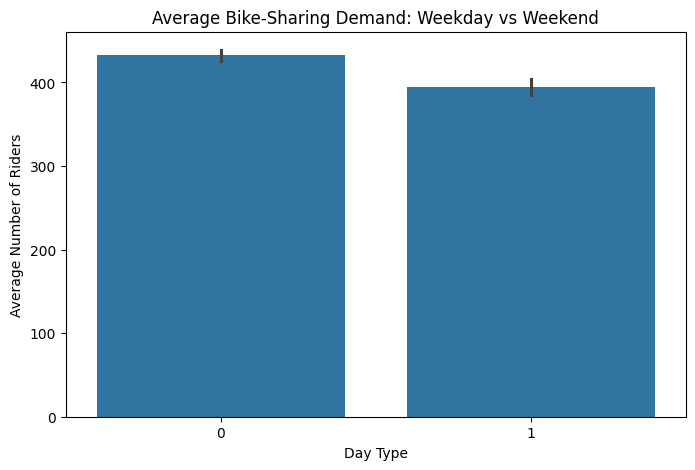

In [ ]:
#4.How does bike-sharing demand differ between weekdays and weekends?
# Bike-Sharing Demand: Weekday vs Weekend
#Categorical vs Numerical
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='IsWeekend',
    y='count',
    estimator='mean'
)

plt.title('Average Bike-Sharing Demand: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Number of Riders')
plt.show()

In [ ]:
#What is the average bike-sharing demand on weekdays?
df[df['IsWeekend'] == 0]['count'].mean()

np.float64(432.5817192889361)

In [ ]:
#What is the average bike-sharing demand on weekends?
df[df['IsWeekend'] == 1]['count'].mean()

np.float64(394.576045310678)

In [ ]:
#Which day type has higher average bike-sharing demand?
df.groupby('IsWeekend')['count'].mean().idxmax()

np.int64(0)

In [ ]:
#Which day type has lower average bike-sharing demand?
df.groupby('IsWeekend')['count'].mean().idxmin()

np.int64(1)

Observations:

1.Bike-sharing demand differs between weekdays and weekends.

2.The average bike-sharing demand on weekdays is approximately 432.58 riders.

3.The average bike-sharing demand on weekends is approximately 394.58 riders.

4.Weekdays have higher average bike-sharing demand than weekends, as shown by the taller bar in the chart.

5.Weekend demand is lower than weekday demand, with an average difference of approximately 38 riders.

6.The weekday average demand is approximately 9.6% higher than the weekend average demand, indicating a moderate difference in usage between the two day types.

6.Overall, bike-sharing demand remains relatively high on both weekdays and weekends, although weekdays show stronger average usage.

Business Insight:

Bike-sharing demand is higher on weekdays than on weekends, suggesting that the service may be used more frequently for regular activities such as commuting and daily travel during weekdays. The business can ensure higher bike availability and operational capacity on weekdays, particularly during peak hours, while using targeted promotions and recreational offers on weekends to encourage additional usage.

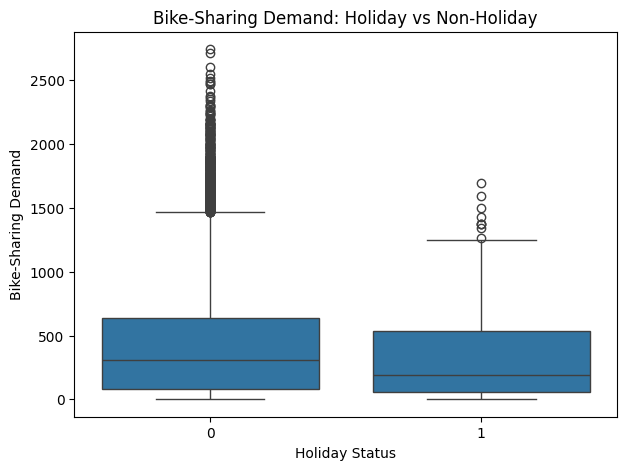

In [ ]:
# Bike-Sharing Demand by Holiday Status
#5.Does holiday status have an impact on bike-sharing demand?
#Categorical vs Numerical
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='IsHoliday',
    y='count'
)

plt.title('Bike-Sharing Demand: Holiday vs Non-Holiday')
plt.xlabel('Holiday Status')
plt.ylabel('Bike-Sharing Demand')

plt.show()

In [ ]:
# What is the average bike-sharing demand on non-holidays?
df[df['IsHoliday'] == 0]['count'].mean()

np.float64(426.00792432271805)

In [ ]:
# What is the average bike-sharing demand on holidays?
df[df['IsHoliday'] == 1]['count'].mean()

np.float64(325.1306306306306)

In [ ]:
# Which has higher average bike-sharing demand: holidays or non-holidays?
df.groupby('IsHoliday')['count'].mean().idxmax()

np.int64(0)

In [ ]:
# Which has lower average bike-sharing demand: holidays or non-holidays?
df.groupby('IsHoliday')['count'].mean().idxmin()

np.int64(1)

In [ ]:
#What is the difference in average bike-sharing demand between holidays and non-holidays?
holiday_avg = df[df['IsHoliday'] == 1]['count'].mean()
nonholiday_avg = df[df['IsHoliday'] == 0]['count'].mean()

abs(nonholiday_avg - holiday_avg)

np.float64(100.87729369208745)

Observations:

1.The average bike-sharing demand on non-holidays is approximately 426.01 riders, while on holidays it is approximately 325.13 riders.

2.Non-holidays have higher average bike-sharing demand than holidays.

3.The average demand on non-holidays is approximately 100.88 riders higher than on holidays.

4.Holiday demand is therefore around 24% lower than non-holiday demand, based on the non-holiday average.

5.The noticeable difference in average demand suggests that holiday status is associated with changes in bike-sharing usage.

6.The lower demand on holidays may indicate that users' regular weekday/work-related travel patterns are reduced during holidays.

Business Insight:

The lower demand during holidays suggests that the business should consider holiday status when planning bike availability and redistribution. More bikes and operational resources can be prioritized for non-holiday periods, while holiday operations can be adjusted based on historically lower demand. Incorporating holiday patterns into demand forecasting can help reduce over-supply and improve resource utilization.

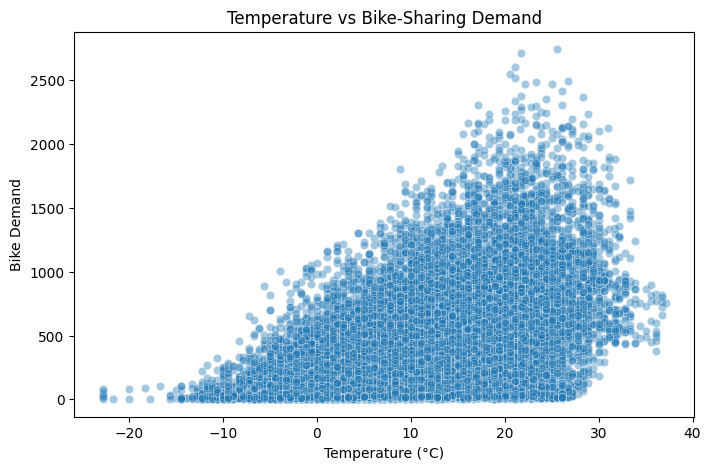

In [ ]:
#6.How are temperature, humidity, and wind speed associated with bike-sharing demand?
#Numerical vs Numerical
#Temperature vs Demand
#How does bike-sharing demand vary with temperature?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Temp(c)',
    y='count',
    alpha=0.4
)

plt.title('Temperature vs Bike-Sharing Demand')
plt.xlabel('Temperature (°C)')
plt.ylabel('Bike Demand')
plt.show()

Observation:

The scatter plot shows that bike-sharing demand generally increases as temperature rises from low to moderate levels. Demand is relatively low at very low temperatures and becomes higher around the moderate-to-warm temperature range. However, the points are widely scattered at higher temperatures, indicating that temperature alone does not completely explain changes in bike-sharing demand.

Business Insight

Temperature is an important factor to consider in bike-sharing demand planning. Operators can expect relatively higher bike usage during comfortable temperature ranges and can prepare sufficient bike availability and redistribution resources accordingly. However, other factors such as time, rider type, day type, and weather conditions should also be considered for more accurate demand planning.

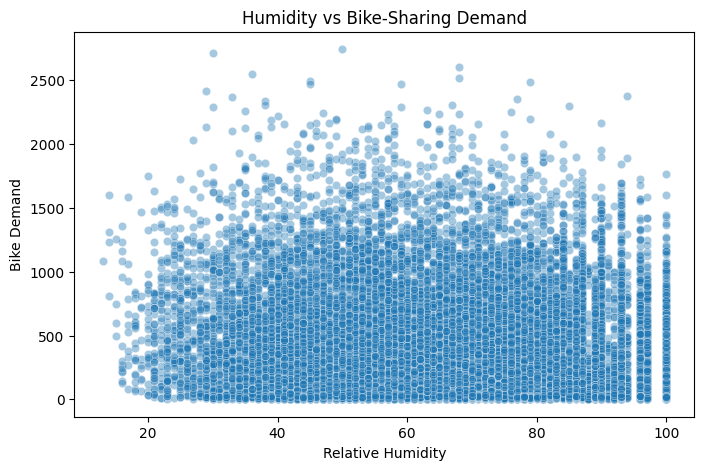

In [ ]:
#Numerical vs Numerical
#Humidity vs Demand
#How does bike-sharing demand vary with humidity?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='rel_humidity',
    y='count',
    alpha=0.4
)

plt.title('Humidity vs Bike-Sharing Demand')
plt.xlabel('Relative Humidity')
plt.ylabel('Bike Demand')
plt.show()

Observation:

The scatter plot shows that bike-sharing demand is widely distributed across different humidity levels. Demand is observed across almost the entire humidity range, with no clear strong increasing or decreasing pattern. This suggests that humidity alone does not have a strong visible relationship with bike-sharing demand.

Business Insight:

Humidity alone may not be a strong predictor of bike-sharing demand. Therefore, operators should consider humidity together with other factors such as temperature, time of day, rider type, weekdays/weekends, and weather conditions when planning bike availability and demand.

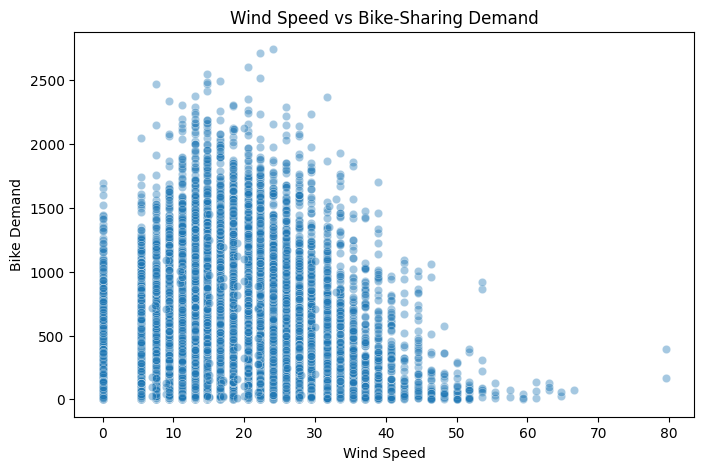

In [ ]:
#Numerical vs Numerical
#Wind Speed vs Demand
#How does bike-sharing demand vary with wind speed?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='wspd',
    y='count',
    alpha=0.4
)

plt.title('Wind Speed vs Bike-Sharing Demand')
plt.xlabel('Wind Speed')
plt.ylabel('Bike Demand')
plt.show()

Observation:

The scatter plot shows that bike-sharing demand is generally higher at low to moderate wind speeds, particularly around 10–30 units. As wind speed increases beyond this range, bike-sharing demand tends to decrease, with relatively few high-demand observations at higher wind speeds. This indicates a negative association between wind speed and bike-sharing demand.

Business Insight:

Higher wind speeds may be associated with reduced bike usage. Therefore, wind conditions can be incorporated into demand forecasting and operational planning. During periods of stronger winds, operators can adjust bike availability and redistribution resources based on the expected lower demand.

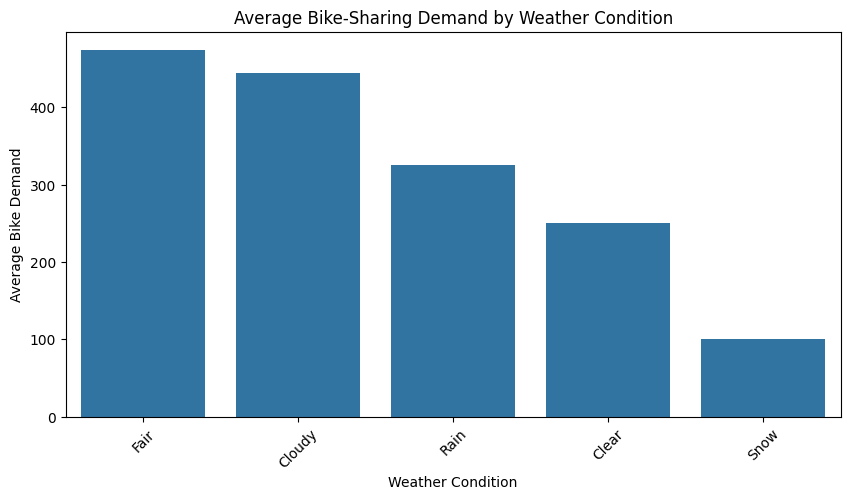

In [ ]:
#7.Which weather conditions are associated with higher or lower bike-sharing demand?
#Categorical vs Numerical
weather_demand = (
    df.groupby('weather_condition')['count']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weather_demand.index,
    y=weather_demand.values
)

plt.title('Average Bike-Sharing Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Bike Demand')
plt.xticks(rotation=45)

plt.show()

In [ ]:
#Which weather condition has the highest average bike-sharing demand?
weather_demand.idxmax()

'Fair'

In [ ]:
#Which weather condition has the lowest average bike-sharing demand?
weather_demand.idxmin()

'Snow'

In [ ]:
#What is the average bike-sharing demand for each weather condition?
weather_demand

,count
weather_condition,
Fair,473.774559
Cloudy,444.767808
Rain,325.198012
Clear,250.115445
Snow,100.904535


In [ ]:
#What is the difference between the highest and lowest average demand across weather conditions?
weather_demand.max() - weather_demand.min()

372.87002421732416

Observation:

The bar chart shows that average bike-sharing demand varies considerably across weather conditions. Fair weather has the highest average demand at approximately 474 rides, followed by Cloudy weather at approximately 445 rides. Demand decreases under Rain and Clear conditions, with average demand of approximately 325 and 250 rides respectively. Snow has the lowest average demand at approximately 101 rides. Overall, the difference between the highest and lowest average demand is approximately 373 ride

Business Insight:

Weather conditions should be considered in bike-sharing demand planning. Fair and Cloudy conditions are associated with higher average demand, so operators may need greater bike availability and redistribution capacity during these conditions. Demand is substantially lower during Snow and Rain, suggesting that bike availability and operational resources can be adjusted based on expected weather-related demand.

Multivariate Analysis

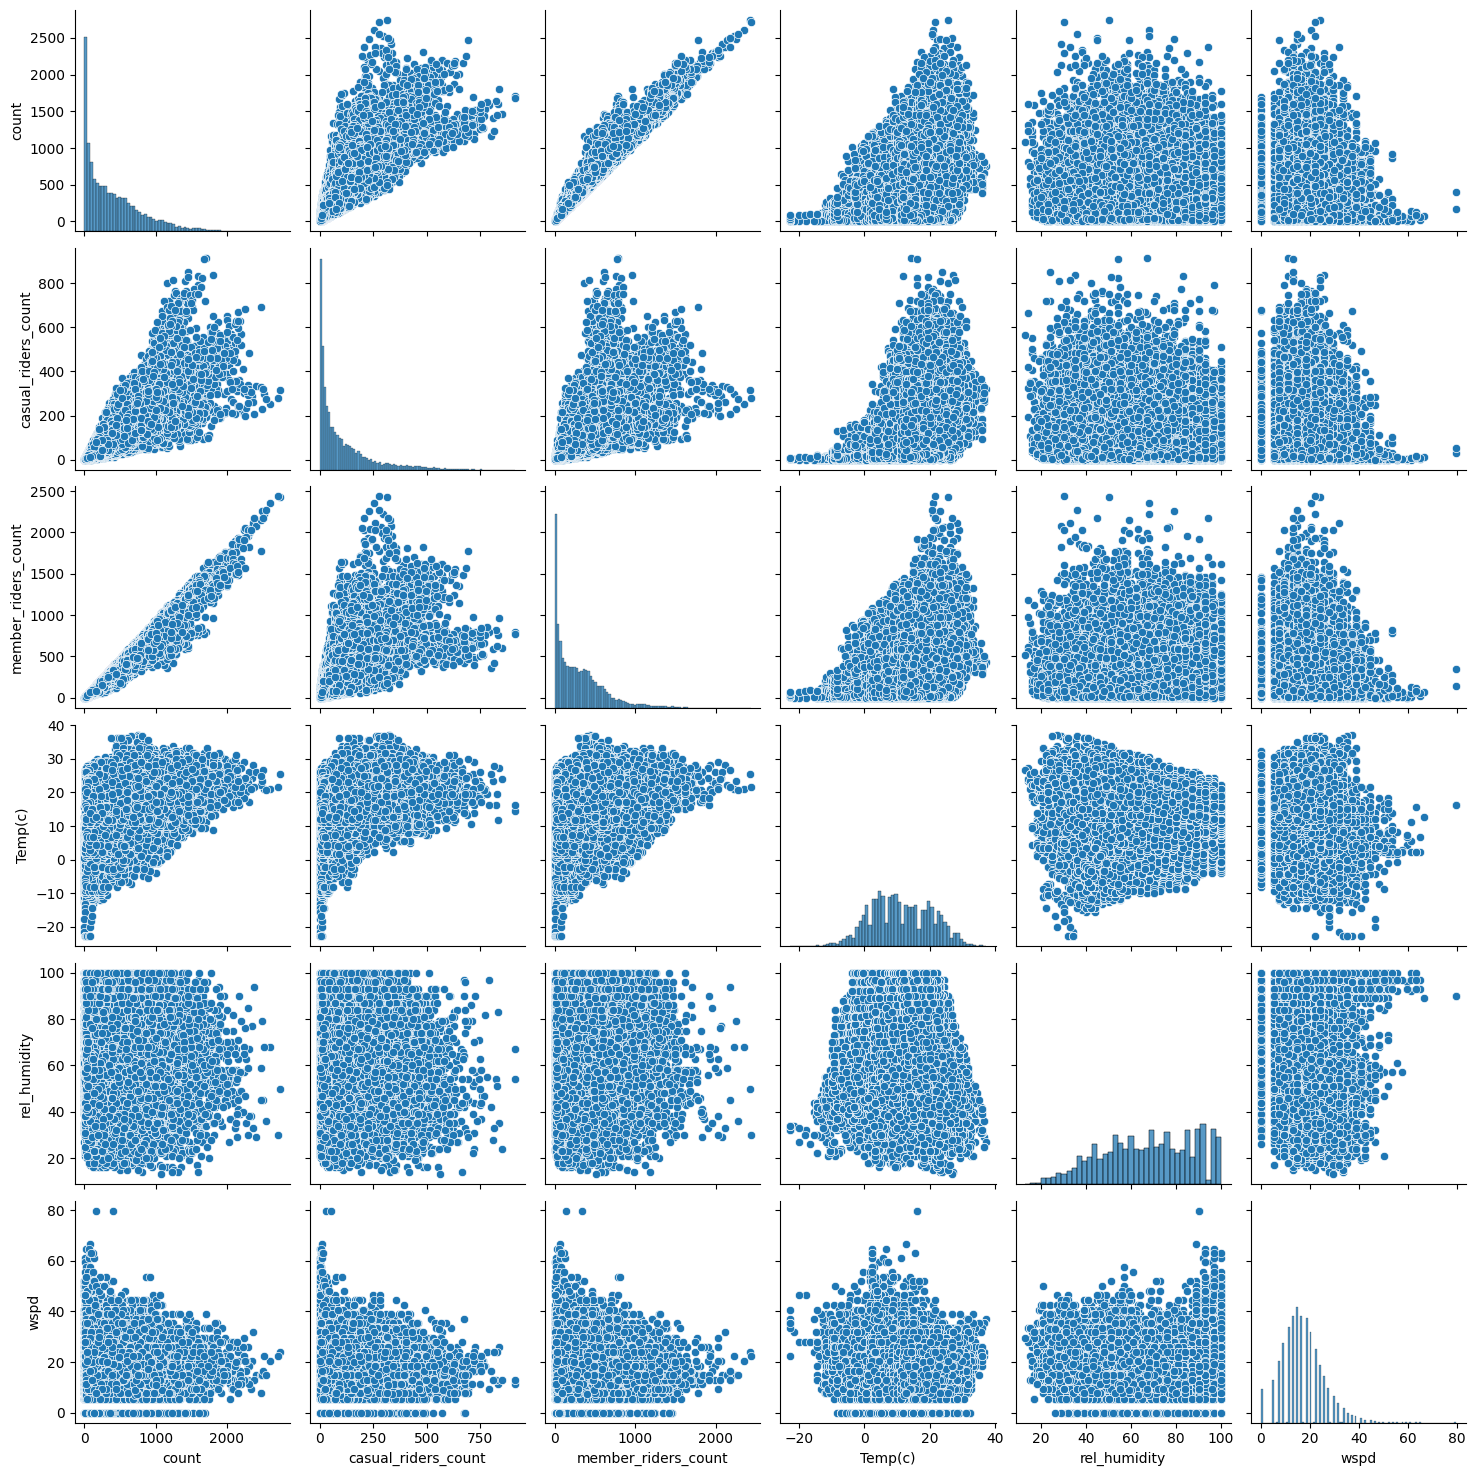

In [ ]:
#8.What patterns in time, rider behavior, and weather can help improve bike availability and demand planning?
#How are bike demand, rider behavior, and weather variables related to each other?
pair_cols = [
    'count',
    'casual_riders_count',
    'member_riders_count',
    'Temp(c)',
    'rel_humidity',
    'wspd'
]

sns.pairplot(df[pair_cols])

plt.show()

Observations:

1.Bike-sharing demand (count) shows a strong positive relationship with member rider count, indicating that higher overall demand is generally associated with higher member usage.

2.Bike-sharing demand also shows a positive relationship with casual rider count, although the relationship appears more dispersed compared with member riders.

3.Member rider count has a particularly strong positive relationship with total bike-sharing demand, suggesting that member riders form a major component of overall demand.

4.Temperature shows a positive association with bike-sharing demand and rider activity, with higher demand generally occurring across more moderate-to-warmer temperature ranges.

5.Humidity does not show a clear strong linear relationship with total bike-sharing demand in the pair plot. The observations are widely scattered across different humidity levels.

6.Wind speed shows a generally negative association with bike-sharing demand and rider activity, with higher wind speeds tending to occur alongside lower demand.

7.The distributions on the diagonal show that demand and rider counts are concentrated at lower values, with fewer observations at very high levels, indicating that extremely high usage occurs less frequently.

8.Overall, the pair plot suggests that rider behavior has a stronger visible association with total demand than the individual weather variables, while weather conditions appear to influence demand to varying degrees.

Business Insight:

The multivariate analysis indicates that rider behavior, particularly member usage, is strongly associated with overall bike-sharing demand, while weather variables such as temperature and wind speed also show meaningful patterns. The business can use these relationships to improve demand forecasting, ensure sufficient bike availability during periods of expected high demand, and optimize operations when unfavorable weather conditions are likely to reduce usage.

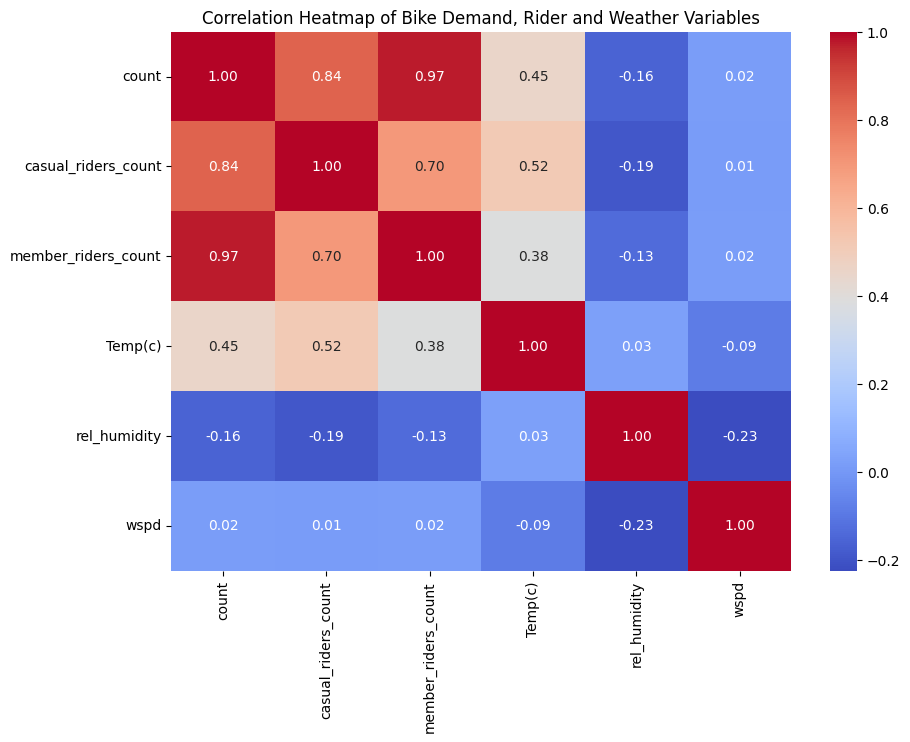

In [ ]:
#What are the correlations among bike demand, rider behavior, and weather variables?
corr_cols = [
    'count',
    'casual_riders_count',
    'member_riders_count',
    'Temp(c)',
    'rel_humidity',
    'wspd'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Bike Demand, Rider and Weather Variables')

plt.show()


Observations:

1.Total bike-sharing demand (count) has a very strong positive correlation with member riders (0.97), indicating that member rider activity is closely associated with overall bike-sharing demand.

2.Total demand also has a strong positive correlation with casual riders (0.84), showing that casual riders also contribute substantially to overall demand.

3.Casual and member riders have a positive correlation of 0.70, indicating that their usage generally tends to increase together.

4.Temperature has a moderate positive correlation with total demand (0.45), suggesting that warmer temperatures are generally associated with higher bike-sharing demand.

5.Temperature has a moderate positive correlation with casual riders (0.52), while its correlation with member riders is somewhat lower (0.38).

6.Relative humidity has a weak negative correlation with total demand (-0.16), indicating only a limited inverse relationship between humidity and bike-sharing demand.

7.Wind speed has almost no correlation with total demand (0.02), suggesting that there is no meaningful linear relationship between wind speed and overall demand in this dataset.

8.Humidity and wind speed have a weak negative correlation (-0.23), while temperature and humidity have almost no linear correlation (0.03).

Business Insight:

The correlation analysis shows that rider activity, particularly member usage, has the strongest association with overall bike-sharing demand. Temperature also shows a moderate positive relationship with demand, while humidity has only a weak negative association and wind speed has almost no linear relationship with demand. Therefore, the business can prioritize rider behavior and temperature when developing demand forecasting models, while treating humidity and wind speed as secondary factors. This can help improve bike availability planning and operational resource allocation.

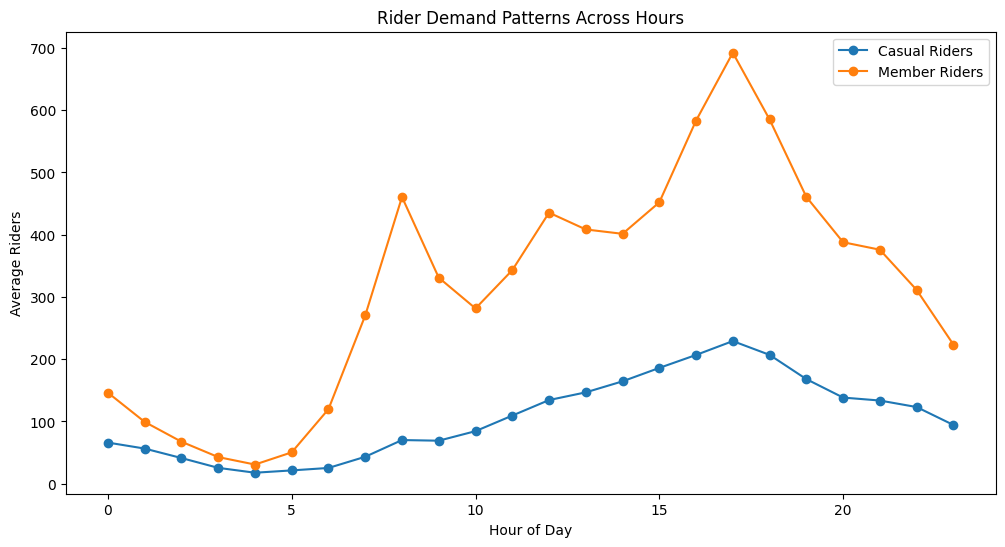

In [ ]:
 #How does bike-sharing demand vary across different hours while considering rider behavior?
rider_hour = df.groupby('HOUR')[
    ['casual_riders_count', 'member_riders_count']
].mean()

plt.figure(figsize=(12,6))

plt.plot(
    rider_hour.index,
    rider_hour['casual_riders_count'],
    marker='o',
    label='Casual Riders'
)

plt.plot(
    rider_hour.index,
    rider_hour['member_riders_count'],
    marker='o',
    label='Member Riders'
)

plt.title('Rider Demand Patterns Across Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Average Riders')
plt.legend()

plt.show()

Observations:

1.Rider activity varies considerably across different hours of the day for both casual and member riders.

2.Member riders consistently show higher average usage than casual riders across almost all hours, indicating stronger and more regular usage among members.

3.Both rider groups experience their lowest average usage during the early-morning hours, particularly around 4 AM–5 AM.

4.Member rider activity increases sharply from the early morning and reaches a major peak around 8 AM, followed by a temporary decline during the late morning.

5.A second and much stronger increase occurs during the afternoon, with member rider usage reaching its highest level around 5 PM, at approximately 690 riders.

6.Casual rider activity also increases during the afternoon and reaches its highest level around 5 PM, at approximately 230 riders.

7.After the 5 PM peak, both member and casual rider activity gradually declines during the evening and late-night hours.

8.The evening peak is more pronounced for member riders than casual riders, showing that member usage is particularly strong during the late-afternoon period.

Business Insight:

The hourly rider patterns show that member riders generate substantially higher usage throughout the day, with the strongest activity occurring during the evening peak around 5 PM. The business can use these rider-specific hourly patterns to improve bike availability and operational planning, particularly by ensuring sufficient bike supply and service capacity during peak periods. At the same time, lower-demand early-morning periods can be used for maintenance, redistribution, and other operational activities.

KEY INSIGHTS:

1.Bike-sharing demand varies significantly across different hours of the day, with certain time periods showing consistently higher usage.

2.Demand patterns differ across days of the week, indicating that day of the week is an important factor in understanding bike usage.

3.Non-holiday days recorded higher typical bike-sharing demand compared with holidays.

4.Member and casual riders show different usage patterns, indicating distinct rider behavior and mobility needs.

5.Fair weather recorded the highest average bike-sharing demand, at approximately 473.77 rides.

6.Cloudy weather recorded the second-highest average demand, at approximately 444.77 rides.

7.Rain was associated with a lower average demand of approximately 325.20 rides.

8.Clear conditions recorded an average demand of approximately 250.12 rides.

9.Snow recorded the lowest average bike-sharing demand, at approximately 100.90 rides.

10.The difference between the highest average demand (Fair) and lowest average demand (Snow) was approximately 372.87 rides, highlighting substantial variation across weather conditions.

11.Temperature showed a positive association with bike-sharing demand, particularly across low to moderate temperature ranges.

12.Humidity showed no strong visible linear relationship with bike-sharing demand.

13.Higher wind speeds were generally associated with lower bike-sharing demand.

14.The combined analysis of time, rider behavior, and weather provides useful insights for understanding variations in bike-sharing demand.

15.These patterns can help identify periods where greater bike availability and redistribution may be required.

FINAL RECOMMENDATIONS

1.Improve peak-period bike availability by allocating more bikes during consistently high-demand hours.

2.Use day-of-week demand patterns to plan bike redistribution and operational resources more effectively.

3.Develop rider-specific strategies for casual and member riders based on their different usage patterns.

4.Incorporate weather conditions into demand planning, especially because demand varies substantially across weather conditions.

5.Prepare for higher demand during Fair and Cloudy weather by maintaining sufficient bike availability and redistribution capacity.

6.Adjust operational resources during Rain and Snow conditions based on the expected lower demand.

7.Include temperature in demand forecasting,
particularly when predicting changes in bike usage across different temperature ranges.

8.Consider wind speed as a supporting weather factor, as higher wind speeds are associated with comparatively lower demand.

9.Avoid relying on a single weather variable for forecasting; combine weather, time, rider type, and calendar factors for better planning.

10.Use historical demand patterns to optimize bike redistribution, ensuring bikes are positioned where and when demand is expected to be highest.

11.Develop a demand monitoring system that can help operators identify upcoming high-demand periods and adjust bike availability proactively.

12.Track operational KPIs such as average demand, peak-hour demand, rider-type demand,weather-related demand, and bike availability to continuously improve operations.


CONCLUSION

The Urban Mobility Intelligence project provides valuable insights into the patterns and factors associated with Boston Blue Bikes demand. The analysis revealed meaningful variations in bike-sharing usage across hours, days, rider types, holidays, and weather conditions. Differences were observed between casual and member riders, while weather conditions such as Fair, Rain, and Snow showed substantial differences in average bike-sharing demand. Temperature and wind speed also showed observable associations with bike usage, whereas humidity displayed a weaker visible relationship.

Overall, the findings demonstrate that bike-sharing demand is influenced by a combination of temporal, behavioral, calendar, and weather-related factors. By combining these insights, bike-sharing operators can improve demand forecasting, bike availability, redistribution, and operational resource planning. This analysis provides a data-driven foundation for making more efficient operational decisions and improving the overall reliability of bike-sharing services.